# NN Eigenfunction Solver: $LQ_1 = \lambda_R Q_1$
## Generator eigenfunction for 3-mode stochastic NLS
- Data: backward_NLS_X.txt, backward_NLS_Q1.txt
- $\lambda_R = -0.934$ (from MC backward solver)
- PDE constraint: $LQ = \lambda_R Q$ where $L = \sum b_i \partial_i + \sum D_i \partial_i^2$

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube

# Parameters
gam = tf.constant(0.1, dtype=tf.float32)
T1  = tf.constant(5.0, dtype=tf.float32)
T3  = tf.constant(5.0, dtype=tf.float32)
lamR = tf.constant(-0.934, dtype=tf.float32)

# Load Q1 data from backward solver
X_data = np.loadtxt('backward_NLS_X.txt', dtype=np.float32)
Q1_data = np.loadtxt('backward_NLS_Q1.txt', dtype=np.float32)

# Normalize Q1 for training
Q1_mean = Q1_data.mean()
Q1_std = Q1_data.std()
Q1_norm = (Q1_data - Q1_mean) / Q1_std

print(f'Data points: {len(X_data)}')
print(f'Q1 range: [{Q1_data.min():.3f}, {Q1_data.max():.3f}]')
print(f'Q1 mean={Q1_mean:.4f}, std={Q1_std:.4f}')

# LHS collocation points for PDE loss
I_max = 10.0
sampler = LatinHypercube(d=5, seed=99)
lhs_raw = sampler.random(n=50000).astype(np.float32)
X_colloc = np.column_stack([
    lhs_raw[:,0] * (I_max - 0.1) + 0.1,
    lhs_raw[:,1] * (I_max - 0.1) + 0.1,
    lhs_raw[:,2] * (I_max - 0.1) + 0.1,
    lhs_raw[:,3] * 2*np.pi - np.pi,
    lhs_raw[:,4] * 2*np.pi - np.pi
])
print(f'Collocation points: {len(X_colloc)}')

Data points: 33603
Q1 range: [-0.925, 1.605]
Q1 mean=0.0346, std=0.5342
Collocation points: 50000


In [12]:
# ============================================================
# Generator L (NOT L†)
# Lf = Σ b_i ∂f/∂x_i + Σ D_i ∂²f/∂x_i²
# Same drift b_i as in FP notebook, same diffusion D_i
# But NO divergence terms (those are in L† only)
# ============================================================
def compute_drift(x):
    I1, I2, I3 = x[...,0], x[...,1], x[...,2]
    th1, th3   = x[...,3], x[...,4]
    s1, c1 = tf.math.sin(th1), tf.math.cos(th1)
    s3, c3 = tf.math.sin(th3), tf.math.cos(th3)
    b_I1  = 4*I1*I2*s1 - 4*gam*I1*I2*(1+c1) + 4*gam*T1 - 2*gam*(I1*I1 + 2*I1*I3)
    b_I2  = -4*I2*(I1*s1 + I3*s3)
    b_I3  = 4*I3*I2*s3 - 4*gam*I3*I2*(1+c3) + 4*gam*T3 - 2*gam*(I3*I3 + 2*I1*I3)
    b_th1 = 2*(I2-I1) + 4*(I2-I1)*c1 + 4*gam*I2*s1 - 4*I3*c3
    b_th3 = 2*(I2-I3) + 4*(I2-I3)*c3 + 4*gam*I2*s3 - 4*I1*c1
    return b_I1, b_I2, b_I3, b_th1, b_th3

# Diffusion coefficients: D_i (same as in FP notebook)
# D_I1 = 4*gam*T1*I1,  D_I3 = 4*gam*T3*I3
# D_th1 = 4*gam*T1/I1, D_th3 = 4*gam*T3/I3
# D_I2 = 0, no diffusion on I2

In [13]:
# ============================================================
# Neural network with periodic encoding
# ============================================================
init = tf.keras.initializers.GlorotUniform()
reg  = tf.keras.regularizers.l2(1e-4)

inp = tf.keras.layers.Input(shape=(5,))

@tf.keras.utils.register_keras_serializable()
def periodic_encode(x):
    I_vars = x[:, :3]
    cos_th1 = tf.math.cos(x[:, 3:4])
    sin_th1 = tf.math.sin(x[:, 3:4])
    cos_th3 = tf.math.cos(x[:, 4:5])
    sin_th3 = tf.math.sin(x[:, 4:5])
    return tf.concat([I_vars, cos_th1, sin_th1, cos_th3, sin_th3], axis=-1)

encoded = tf.keras.layers.Lambda(periodic_encode)(inp)

h = tf.keras.layers.Dense(32,  activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(encoded)
h = tf.keras.layers.Dense(256, activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(256, activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(128, activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(64,  activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(16,  activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
out = tf.keras.layers.Dense(1)(h)

model = tf.keras.models.Model(inp, out)
model.summary()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
batch_size = 64

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,705 (455.88 KB)

 Trainable params: 116,705 (455.88 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ============================================================
# Training step: data loss + PDE loss (LQ = λQ)
# ============================================================
Q_mu  = tf.constant(Q1_mean, dtype=tf.float32)
Q_sig = tf.constant(Q1_std, dtype=tf.float32)

@tf.function
def train_step(X_b, Y_b, X_c, w_data=1.0, w_pde=0.1):
    with tf.GradientTape(persistent=True) as tp:
        tp.watch(X_c)

        # --- data loss ---
        pred = model(X_b, training=True)[...,0]
        loss_data = tf.reduce_mean(tf.square(Y_b - pred))

        # --- PDE loss: LQ = λ_R * Q ---
        # Q = Q_sig * u + Q_mu (denormalize)
        u = model(X_c, training=True)[...,0]
        Q = Q_sig * u + Q_mu

        # First derivatives of Q
        gQ = tp.gradient(tf.reduce_sum(Q), X_c)
        dQ1, dQ2, dQ3, dQ4, dQ5 = gQ[...,0], gQ[...,1], gQ[...,2], gQ[...,3], gQ[...,4]

        # Second derivatives of Q
        dQ11 = tp.gradient(tf.reduce_sum(dQ1), X_c)[...,0]
        dQ33 = tp.gradient(tf.reduce_sum(dQ3), X_c)[...,2]
        dQ44 = tp.gradient(tf.reduce_sum(dQ4), X_c)[...,3]
        dQ55 = tp.gradient(tf.reduce_sum(dQ5), X_c)[...,4]

        # Diffusion coefficients
        I1 = tf.math.maximum(X_c[...,0], 1e-6)
        I3 = tf.math.maximum(X_c[...,2], 1e-6)
        D_I1 = 4*gam*T1*I1
        D_I3 = 4*gam*T3*I3
        D_th1 = 4*gam*T1/I1
        D_th3 = 4*gam*T3/I3

        # LQ = b·∇Q + D·∇²Q
        bI1, bI2, bI3, bt1, bt3 = compute_drift(X_c)
        advection = bI1*dQ1 + bI2*dQ2 + bI3*dQ3 + bt1*dQ4 + bt3*dQ5
        diffusion = D_I1*dQ11 + D_I3*dQ33 + D_th1*dQ44 + D_th3*dQ55

        LQ = advection + diffusion
        residual = LQ - lamR * Q
        loss_pde = tf.reduce_mean(tf.square(residual / (tf.abs(Q) + 1e-6)))

        # --- combined ---
        loss = w_data * loss_data + w_pde * loss_pde

    grads = tp.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    return loss_data, loss_pde

In [15]:
# ============================================================
# Phase 1: data-only pretrain (80 epochs)
# ============================================================
N_data = len(X_data)
N_colloc = len(X_colloc)

for epoch in range(80):
    idx = np.random.permutation(N_data)
    total_data_loss = 0
    n_batches = 0
    for start in range(0, N_data, batch_size):
        end = min(start + batch_size, N_data)
        ib = idx[start:end]
        ic = np.random.choice(N_colloc, size=len(ib), replace=False)
        ld, lp = train_step(
            tf.constant(X_data[ib]),
            tf.constant(Q1_norm[ib]),
            tf.constant(X_colloc[ic]),
            w_data=1.0, w_pde=0.0)
        total_data_loss += ld.numpy()
        n_batches += 1
    if (epoch+1) % 10 == 0:
        print(f'Phase 1 epoch {epoch+1:3d}: data_loss={total_data_loss/n_batches:.6f}')

Phase 1 epoch  10: data_loss=0.097020
Phase 1 epoch  20: data_loss=0.060089
Phase 1 epoch  30: data_loss=0.046944
Phase 1 epoch  40: data_loss=0.038758
Phase 1 epoch  50: data_loss=0.030068
Phase 1 epoch  60: data_loss=0.020918
Phase 1 epoch  70: data_loss=0.015180
Phase 1 epoch  80: data_loss=0.011117


In [16]:
# ============================================================
# Phase 2: joint training (500 epochs, w_pde ramp 0→0.5)
# ============================================================
for epoch in range(500):
    # Learning rate schedule
    if epoch == 200:
        optimizer.learning_rate.assign(5e-4)
    if epoch == 350:
        optimizer.learning_rate.assign(2e-4)
    
    # PDE weight ramp
    w_pde = min(0.5, 0.5 * epoch / 100)
    
    idx = np.random.permutation(N_data)
    total_data_loss = 0
    total_pde_loss = 0
    n_batches = 0
    for start in range(0, N_data, batch_size):
        end = min(start + batch_size, N_data)
        ib = idx[start:end]
        ic = np.random.choice(N_colloc, size=len(ib)*2, replace=False)
        ld, lp = train_step(
            tf.constant(X_data[ib]),
            tf.constant(Q1_norm[ib]),
            tf.constant(X_colloc[ic]),
            w_data=1.0, w_pde=w_pde)
        total_data_loss += ld.numpy()
        total_pde_loss += lp.numpy()
        n_batches += 1
    if (epoch+1) % 20 == 0:
        print(f'Phase 2 epoch {epoch+1:3d}: data={total_data_loss/n_batches:.6f}  pde={total_pde_loss/n_batches:.6f}  w_pde={w_pde:.3f}')

# Save model
import os
os.makedirs('h5_files_eigen', exist_ok=True)
model.save('h5_files_eigen/final.keras')
print('Model saved.')

Phase 2 epoch  20: data=1.022131  pde=0.838208  w_pde=0.095
Phase 2 epoch  40: data=1.009556  pde=0.186488  w_pde=0.195
Phase 2 epoch  60: data=1.007014  pde=0.089787  w_pde=0.295
Phase 2 epoch  80: data=1.005927  pde=0.062918  w_pde=0.395
Phase 2 epoch 100: data=1.009897  pde=0.059188  w_pde=0.495
Phase 2 epoch 120: data=0.997948  pde=0.057789  w_pde=0.500
Phase 2 epoch 140: data=1.017837  pde=0.103259  w_pde=0.500
Phase 2 epoch 160: data=0.993212  pde=0.040786  w_pde=0.500
Phase 2 epoch 180: data=0.990277  pde=0.042434  w_pde=0.500
Phase 2 epoch 200: data=0.976199  pde=0.052880  w_pde=0.500
Phase 2 epoch 220: data=0.760281  pde=0.349934  w_pde=0.500
Phase 2 epoch 240: data=0.657978  pde=0.406531  w_pde=0.500
Phase 2 epoch 260: data=0.632443  pde=0.394065  w_pde=0.500
Phase 2 epoch 280: data=0.606688  pde=0.381131  w_pde=0.500
Phase 2 epoch 300: data=0.595151  pde=0.371589  w_pde=0.500
Phase 2 epoch 320: data=0.576591  pde=0.362023  w_pde=0.500
Phase 2 epoch 340: data=0.567080  pde=0.

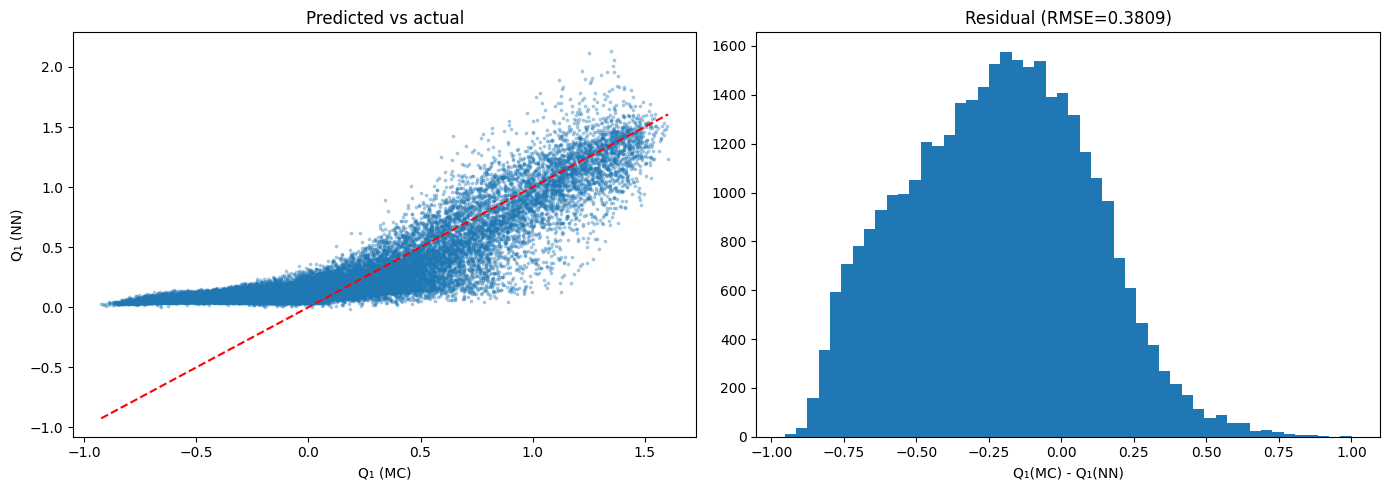

RMSE = 0.3809
Relative RMSE = 0.7131


In [20]:
# ============================================================
# Evaluation: data fit quality
# ============================================================
pred_all = model(X_data, training=False).numpy().flatten()
Q1_pred = Q_sig.numpy() * pred_all + Q_mu.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(Q1_data, Q1_pred, s=3, alpha=0.3)
axes[0].plot([Q1_data.min(), Q1_data.max()], [Q1_data.min(), Q1_data.max()], 'r--')
axes[0].set_xlabel('Q₁ (MC)'); axes[0].set_ylabel('Q₁ (NN)')
axes[0].set_title('Predicted vs actual')

# Residual
rmse = np.sqrt(np.mean((Q1_data - Q1_pred)**2))
axes[1].hist(Q1_data - Q1_pred, bins=50)
axes[1].set_xlabel('Q₁(MC) - Q₁(NN)'); axes[1].set_title(f'Residual (RMSE={rmse:.4f})')

plt.tight_layout(); plt.show()
print(f'RMSE = {rmse:.4f}')
print(f'Relative RMSE = {rmse/Q1_std:.4f}')

|LQ - λQ| / |Q|:
  median = 0.3513
  mean   = 0.4712
  90th   = 1.0464


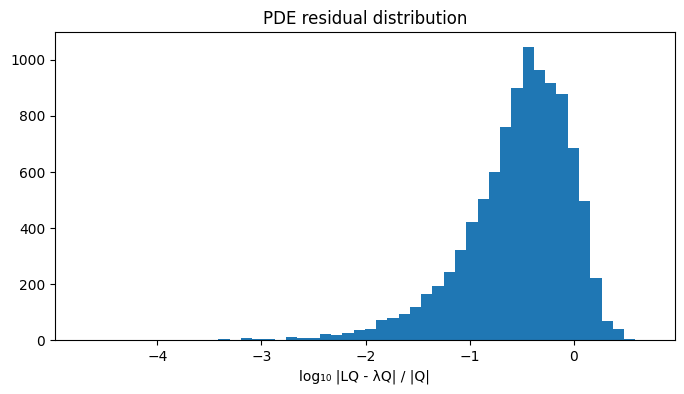

In [18]:
# ============================================================
# PDE residual check: LQ - λQ at collocation points
# ============================================================
X_test = tf.constant(X_colloc[:10000])
with tf.GradientTape(persistent=True) as tp:
    tp.watch(X_test)
    u = model(X_test, training=False)[...,0]
    Q = Q_sig * u + Q_mu
    gQ = tp.gradient(tf.reduce_sum(Q), X_test)
    dQ1, dQ2, dQ3, dQ4, dQ5 = gQ[...,0], gQ[...,1], gQ[...,2], gQ[...,3], gQ[...,4]
    dQ11 = tp.gradient(tf.reduce_sum(dQ1), X_test)[...,0]
    dQ33 = tp.gradient(tf.reduce_sum(dQ3), X_test)[...,2]
    dQ44 = tp.gradient(tf.reduce_sum(dQ4), X_test)[...,3]
    dQ55 = tp.gradient(tf.reduce_sum(dQ5), X_test)[...,4]

I1t = tf.math.maximum(X_test[...,0], 1e-6)
I3t = tf.math.maximum(X_test[...,2], 1e-6)
bI1, bI2, bI3, bt1, bt3 = compute_drift(X_test)
LQ = (bI1*dQ1 + bI2*dQ2 + bI3*dQ3 + bt1*dQ4 + bt3*dQ5 +
      4*gam*T1*I1t*dQ11 + 4*gam*T3*I3t*dQ33 +
      4*gam*T1/I1t*dQ44 + 4*gam*T3/I3t*dQ55)

residual = (LQ - lamR * Q).numpy()
Q_np = Q.numpy()
rel_res = np.abs(residual) / (np.abs(Q_np) + 1e-6)

print(f'|LQ - λQ| / |Q|:')
print(f'  median = {np.median(rel_res):.4f}')
print(f'  mean   = {np.mean(rel_res):.4f}')
print(f'  90th   = {np.percentile(rel_res, 90):.4f}')

plt.figure(figsize=(8,4))
plt.hist(np.log10(rel_res + 1e-10), bins=50)
plt.xlabel('log₁₀ |LQ - λQ| / |Q|'); plt.title('PDE residual distribution')
plt.show()

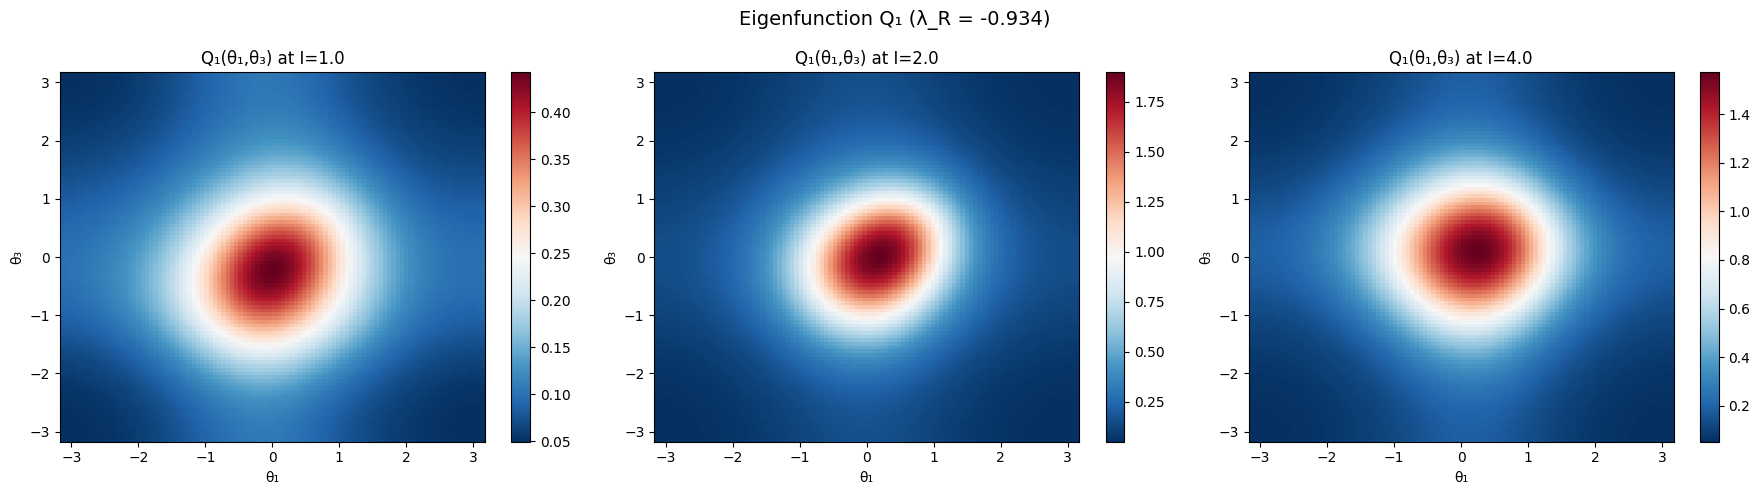

In [19]:
# ============================================================
# Visualize Q1: slices
# ============================================================
N = 100
theta = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
TH1, TH3 = np.meshgrid(theta, theta)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, I_val in enumerate([1.0, 2.0, 4.0]):
    sl = np.column_stack([np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          TH1.ravel(), TH3.ravel()])
    u_pred = model(sl, training=False).numpy().flatten()
    Q_pred = (Q_sig.numpy() * u_pred + Q_mu.numpy()).reshape(N, N)
    im = axes[idx].pcolormesh(theta, theta, Q_pred, cmap='RdBu_r', shading='auto')
    axes[idx].set_title(f'Q₁(θ₁,θ₃) at I={I_val}')
    axes[idx].set_xlabel('θ₁'); axes[idx].set_ylabel('θ₃')
    plt.colorbar(im, ax=axes[idx])

plt.suptitle(f'Eigenfunction Q₁ (λ_R = {lamR.numpy():.3f})', fontsize=14)
plt.tight_layout(); plt.show()